# 05 - Regression-based driving risk score

Goal: build a regression model that predicts a continuous per-window
"risk score" and is evaluated honestly on **unseen drivers**.

There is one big methodological caveat that we make explicit:

> The dataset contains **no ground-truth risk labels**. The target we
> regress on is a *synthetic* composite score built from a small set of
> aggressive-driving indicators (peak brake pressure, lateral-acceleration
> std, etc.). The model is only useful insofar as that synthetic target
> reflects something we believe about risk - it is not a validated
> ground truth.

To avoid the leakage trap (target = a deterministic function of some of
the inputs), we build the target from **a fixed list of source sensors**
and then **remove every statistic of those source sensors** from the
feature matrix before training. So the model has to predict the target
from the *other* sensors. This makes the R^2 a meaningful generalisation
metric rather than a tautology.

We also do driver-grouped cross-validation: the test driver(s) are never
seen during training.


In [14]:
import sys, os
from pathlib import Path

# Make the project root importable so that `import src` works no matter where
# Jupyter was launched from.
HERE = Path(os.getcwd()).resolve()
ROOT = HERE if (HERE / "src").is_dir() else HERE.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root:", ROOT)


project root: C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from src.io import load_cleaned
from src.features import (
    build_window_feature_table, feature_columns, BEHAVIOR_SENSORS, filter_sensors,
)

sns.set_theme(style="whitegrid")
RNG = 42


## 1. Build window features

In [16]:
df = load_cleaned()
windows = build_window_feature_table(df, window_size=10, sensors=BEHAVIOR_SENSORS)
print("windows:", windows.shape)
windows.head()


C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model\src\features.py:57: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  vskew = float(skew(values, bias=False))


windows: (2501, 64)


,driver_id,window_id,global_window_id,n_rows,vehicle_speed__mean,vehicle_speed__std,vehicle_speed__min,vehicle_speed__max,vehicle_speed__range,vehicle_speed__skew,...,steering_wheel_angle__min,steering_wheel_angle__max,steering_wheel_angle__range,steering_wheel_angle__skew,fuel_consumption__mean,fuel_consumption__std,fuel_consumption__min,fuel_consumption__max,fuel_consumption__range,fuel_consumption__skew
0,A,0,A_w0,36,0.000,0.000000,0.0,0.0,0.0,0.000000,...,-3.6,89.7,93.3,5.699610,329.244444,164.767682,192.0,921.6,729.6,2.363371
1,A,1,A_w1,40,2.900,4.176123,0.0,13.0,13.0,1.376923,...,-245.4,488.0,733.4,1.044280,536.640000,215.317678,294.4,1292.8,998.4,1.772139
2,A,2,A_w2,40,5.175,5.238738,0.0,18.0,18.0,0.766754,...,-387.2,335.9,723.1,-0.272988,600.320000,254.182347,307.2,1728.0,1420.8,2.637034
3,A,3,A_w3,40,6.425,4.831602,0.0,16.0,16.0,0.299809,...,-427.5,20.7,448.2,-1.018231,621.440000,249.287189,384.0,1779.2,1395.2,2.784482
4,A,4,A_w4,40,9.650,8.621340,0.0,36.0,36.0,1.524833,...,-378.8,42.2,421.0,-1.715435,935.680000,715.809602,358.4,3072.0,2713.6,1.692251


## 2. Define the synthetic risk target

The target is a robust-scaled mean of six indicators drawn from a fixed
set of "source sensors":


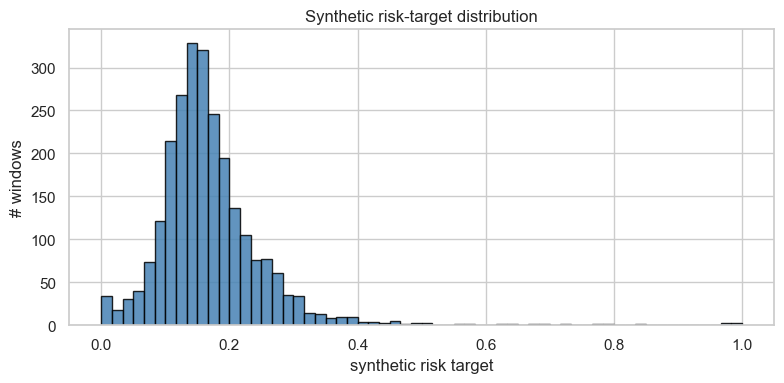

count    2501.000
mean        0.169
std         0.084
min         0.000
25%         0.123
50%         0.157
75%         0.199
max         1.000
Name: risk_target, dtype: float64

In [17]:
TARGET_SOURCE_SENSORS = [
    "master_cylinder_pressure",          # peak brake pressure -> hard braking
    "acceleration_speed_longitudinal",   # accel/brake variability
    "acceleration_speed_lateral",        # cornering aggressiveness
    "steering_wheel_speed",              # jerky steering
    "accelerator_pedal_value",           # throttle bursts
    "vehicle_speed",                     # speed swings
]
target_indicators = [
    "master_cylinder_pressure__max",
    "acceleration_speed_longitudinal__std",
    "acceleration_speed_lateral__std",
    "steering_wheel_speed__std",
    "accelerator_pedal_value__max",
    "vehicle_speed__std",
]
target_indicators = [c for c in target_indicators if c in windows.columns]

ind_scaled = RobustScaler().fit_transform(windows[target_indicators].fillna(0.0))
raw = ind_scaled.mean(axis=1)
windows["risk_target"] = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(windows["risk_target"], bins=60, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_xlabel("synthetic risk target"); ax.set_ylabel("# windows")
ax.set_title("Synthetic risk-target distribution")
plt.tight_layout(); plt.show()
windows["risk_target"].describe().round(3)


## 3. Build the feature matrix - **excluding** target-source sensors

We drop every column derived from the sensors that built the target.
What is left are statistics of engine RPM, fuel consumption, throttle
position signal, and steering *angle* (not steering speed). The model
has to predict the target from these alone.


In [18]:
leak_cols = filter_sensors(windows, TARGET_SOURCE_SENSORS)
all_feats = feature_columns(windows)
safe_feats = [c for c in all_feats if c not in leak_cols and c not in {"risk_target"}]
print(f"raw window features: {len(all_feats)}")
print(f"dropped (target-source): {len(leak_cols)}")
print(f"safe features: {len(safe_feats)}")


raw window features: 61
dropped (target-source): 36
safe features: 24


In [19]:
X = windows[safe_feats].fillna(0.0).to_numpy()
y = windows["risk_target"].to_numpy()
groups = windows["driver_id"].to_numpy()
print("X:", X.shape, " y:", y.shape, " unique drivers:", len(set(groups)))


X: (2501, 24)  y: (2501,)  unique drivers: 10


## 4. Driver-grouped cross-validation

`GroupKFold` guarantees that all windows from any given driver fall
entirely in either the train or the test fold, never both. This is the
right evaluation for a model that should generalise to *new drivers*.


In [20]:
cv = GroupKFold(n_splits=5)
candidates = {
    "Ridge":            Ridge(alpha=1.0, random_state=RNG),
    "RandomForest":     RandomForestRegressor(n_estimators=200, max_depth=None,
                                              random_state=RNG, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                  learning_rate=0.05, random_state=RNG),
}

rows = []
for name, model in candidates.items():
    r2 = cross_val_score(model, X, y, groups=groups, cv=cv, scoring="r2", n_jobs=-1)
    nmae = -cross_val_score(model, X, y, groups=groups, cv=cv,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
    rows.append({"model": name,
                 "r2_mean": r2.mean(), "r2_std": r2.std(),
                 "mae_mean": nmae.mean(), "mae_std": nmae.std()})
cv_results = pd.DataFrame(rows).round(4)
cv_results


,model,r2_mean,r2_std,mae_mean,mae_std
0,Ridge,0.3758,0.0852,0.0365,0.0016
1,RandomForest,0.4215,0.1405,0.0354,0.0029
2,GradientBoosting,0.4314,0.1140,0.0355,0.0024


A few of the folds may show a *negative* R^2 - that's the honest
signal that the held-out driver doesn't behave like the training pool.
With no labels, the synthetic target is still partly idiosyncratic per
driver, and the model can't perfectly recover that from the remaining
sensors.


## 5. Fit the best model on a single hold-out split

In [21]:
best_name = cv_results.sort_values("r2_mean", ascending=False).iloc[0]["model"]
print("best model:", best_name)
best_model = candidates[best_name]

# Pick 2 random drivers as the test set, train on the rest.
rng = np.random.default_rng(RNG)
drivers = sorted(set(groups))
test_drivers = rng.choice(drivers, size=2, replace=False).tolist()
train_mask = ~np.isin(groups, test_drivers)
test_mask = np.isin(groups, test_drivers)
print("test drivers:", test_drivers)
print("train windows:", train_mask.sum(), " test windows:", test_mask.sum())

best_model.fit(X[train_mask], y[train_mask])
y_pred_train = best_model.predict(X[train_mask])
y_pred_test = best_model.predict(X[test_mask])

def report(y_true, y_pred, split):
    print(f"[{split}] R^2 = {r2_score(y_true, y_pred):.3f}  "
          f"RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}  "
          f"MAE = {mean_absolute_error(y_true, y_pred):.4f}")

report(y[train_mask], y_pred_train, "train")
report(y[test_mask],  y_pred_test,  "test ")


best model: GradientBoosting
test drivers: ['A', 'H']
train windows: 2010  test windows: 491
[train] R^2 = 0.846  RMSE = 0.0315  MAE = 0.0229
[test ] R^2 = 0.544  RMSE = 0.0657  MAE = 0.0367


## 6. Diagnostics

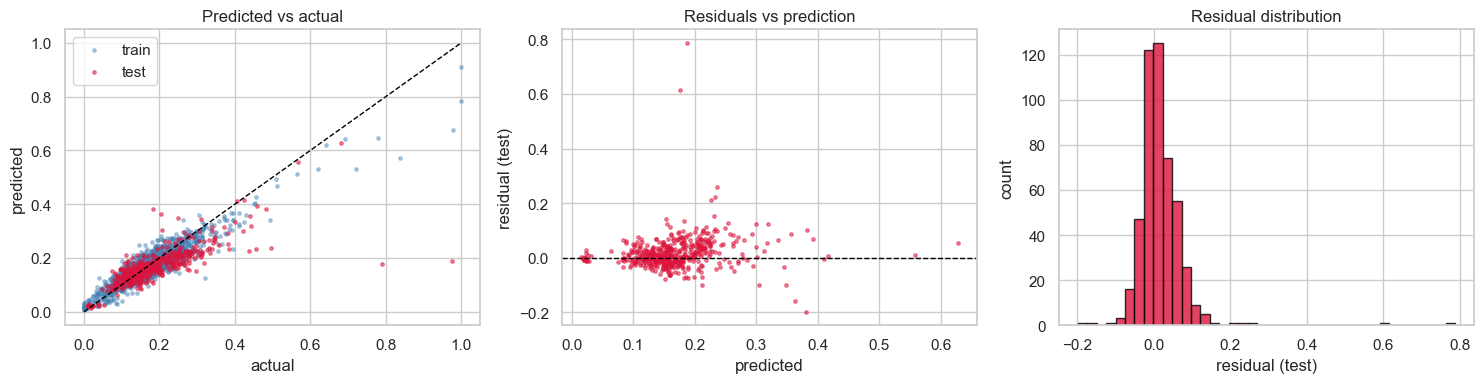

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y[train_mask], y_pred_train, s=6, alpha=0.4, color="steelblue", label="train")
axes[0].scatter(y[test_mask],  y_pred_test,  s=6, alpha=0.5, color="crimson", label="test")
lo, hi = float(min(y.min(), y_pred_train.min(), y_pred_test.min())),          float(max(y.max(), y_pred_train.max(), y_pred_test.max()))
axes[0].plot([lo, hi], [lo, hi], "--", color="black", lw=1)
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted")
axes[0].set_title("Predicted vs actual")
axes[0].legend()

residuals_test = y[test_mask] - y_pred_test
axes[1].scatter(y_pred_test, residuals_test, s=6, alpha=0.5, color="crimson")
axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual (test)")
axes[1].set_title("Residuals vs prediction")

axes[2].hist(residuals_test, bins=40, color="crimson", edgecolor="black", alpha=0.8)
axes[2].set_xlabel("residual (test)"); axes[2].set_ylabel("count")
axes[2].set_title("Residual distribution")

plt.tight_layout(); plt.show()


### Feature importance

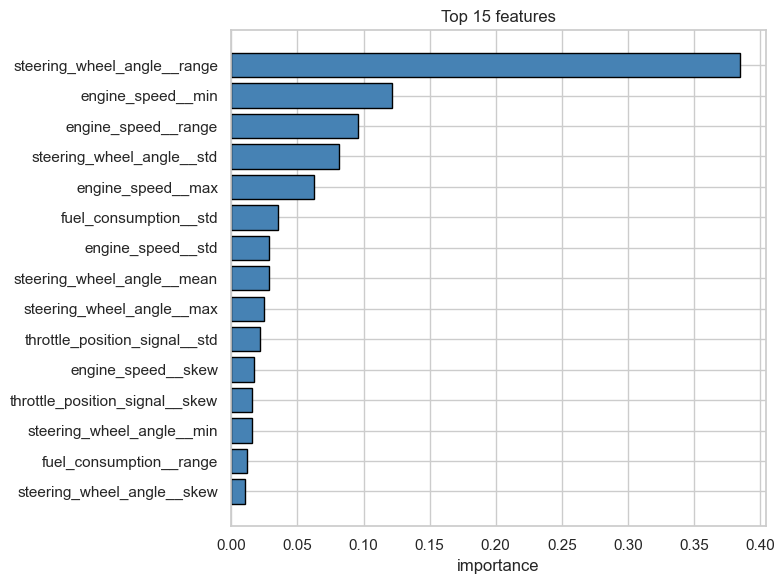

In [23]:
if hasattr(best_model, "feature_importances_"):
    imp = (pd.DataFrame({"feature": safe_feats,
                         "importance": best_model.feature_importances_})
             .sort_values("importance", ascending=False).head(15))
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color="steelblue", edgecolor="black")
    ax.set_xlabel("importance"); ax.set_title("Top 15 features")
    plt.tight_layout(); plt.show()
    imp
else:
    print(best_name, "does not expose feature_importances_")


## 7. Per-driver risk roll-up

Mean predicted risk score per driver, ranked. We rate the top third as
"dangerous", the middle third as "moderate", the bottom third as "safe".
Same caveat as before - these are buckets over a synthetic target, not a
validated risk classification.


In [24]:
windows["risk_predicted"] = best_model.predict(X)
driver_risk = (windows.groupby("driver_id")
                       .agg(n_windows=("global_window_id", "count"),
                            risk_target_mean=("risk_target", "mean"),
                            risk_predicted_mean=("risk_predicted", "mean"))
                       .round(4)
                       .sort_values("risk_predicted_mean", ascending=False))

# Tertiles -> safe / moderate / dangerous
labels = ["dangerous", "moderate", "safe"]
driver_risk["bucket"] = pd.qcut(driver_risk["risk_predicted_mean"], q=3, labels=labels)
driver_risk


,n_windows,risk_target_mean,risk_predicted_mean,bucket
driver_id,,,,
C,202,0.1980,0.1868,safe
A,203,0.2227,0.1826,safe
D,264,0.1676,0.1783,safe
B,256,0.1647,0.1710,moderate
I,217,0.1707,0.1632,moderate
F,294,0.1537,0.1592,moderate
H,288,0.1601,0.1589,dangerous
J,295,0.1645,0.1571,dangerous
G,204,0.1425,0.1546,dangerous


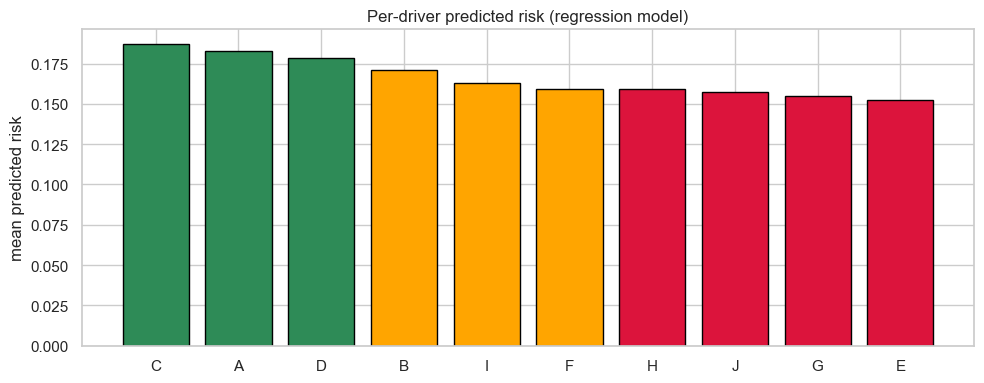

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
color_map = {"safe": "seagreen", "moderate": "orange", "dangerous": "crimson"}
colors = [color_map[str(b)] for b in driver_risk["bucket"]]
ax.bar(driver_risk.index, driver_risk["risk_predicted_mean"], color=colors, edgecolor="black")
ax.set_ylabel("mean predicted risk")
ax.set_title("Per-driver predicted risk (regression model)")
plt.tight_layout(); plt.show()


## 8. Save model + outputs

In [26]:
MODEL_PATH = ROOT / "models" / "risk_model.pkl"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"model": best_model, "features": safe_feats,
             "target_source_sensors": TARGET_SOURCE_SENSORS}, MODEL_PATH)
print("saved:", MODEL_PATH.relative_to(ROOT))

OUT_DIR = ROOT / "reports" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
windows[["driver_id", "window_id", "global_window_id",
         "risk_target", "risk_predicted"]].to_csv(
    OUT_DIR / "risk_assessment_results.csv", index=False)
driver_risk.to_csv(OUT_DIR / "driver_risk_summary_regression.csv")
print("saved:", (OUT_DIR / "risk_assessment_results.csv").relative_to(ROOT))
print("saved:", (OUT_DIR / "driver_risk_summary_regression.csv").relative_to(ROOT))


saved: models\risk_model.pkl
saved: reports\outputs\risk_assessment_results.csv
saved: reports\outputs\driver_risk_summary_regression.csv
